# YouTube Helper Agent

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from typing import TypedDict, Optional, List, Dict
from pydantic import BaseModel,Field

In [2]:
load_dotenv()

# Initialize the Groq LLM
llm = ChatGroq(
    temperature=0,
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model_name="openai/gpt-oss-20b"
)

response = llm.invoke( "Genrate 4 ideas about space" )
response.content

'Here are four fresh, cross‑disciplinary ideas that revolve around the theme of space:\n\n| # | Idea | What it is | Why it’s exciting |\n|---|------|------------|-------------------|\n| 1 | **“Orbit‑to‑Orbit” Modular Space Habitat** | A stackable, inflatable habitat that can be launched as a single unit and then assembled in orbit into a larger, multi‑module living/working space. | It reduces launch mass and cost, allows rapid expansion, and could serve as a low‑orbit research station or a staging point for deeper‑space missions. |\n| 2 | **Deep‑Space Weather Forecasting AI** | A machine‑learning system that ingests solar‑wind, magnetospheric, and cosmic‑ray data from multiple spacecraft to predict space‑weather events (e.g., solar flares, CMEs) with days‑ahead lead time. | Protects satellites, astronauts, and future crewed missions; could be commercialized for satellite operators and space agencies. |\n| 3 | **“Stellar Cookbook” – Culinary Experiments in Microgravity** | A series of e

### Sate Graph

In [3]:
class YoutubeHelperState(TypedDict):
    user_request : str
    video_ideas : Optional[ List[str] ]
    filtered_idea : Optional[str]
    final_video_script : Optional[str]

### First node ( Ideas Generator )

In [4]:
def IdeasGeneratorNode( state:YoutubeHelperState ) -> Dict:

    class IdeasList( BaseModel ):
        video_ideas : List[str] = Field( ..., description="A list of unique and engaging YouTube video ideas based on the user's request.",
                                         min_items=3, max_items=5 )

    prompt = "\n".join([
        "You are a creative YouTube content creator.",
        "Based on the user's request, generate a list of unique and engaging YouTube video ideas.",
        "Ensure that the ideas are relevant to the user's request and are likely to attract viewers.",
        "User request:",
        f"{state['user_request']}",
    ] )

    llm_with_structured_output = llm.with_structured_output( IdeasList )

    response:IdeasList = llm_with_structured_output.invoke(prompt)
    print( f"response : {response}" )

    return {
        "video_ideas" : response.video_ideas
    }



In [5]:
state_1 = YoutubeHelperState( user_request="Create YouTube video ideas about AI agents." )
node_output = IdeasGeneratorNode( state=state_1 )

response : video_ideas=['Exploring the Future: How AI Agents Will Transform Everyday Life', 'Building Your Own AI Agent: A Step-by-Step Tutorial for Beginners', 'AI Agent Showdown: Comparing the Top 5 AI Assistants in 2025', 'The Ethics of AI Agents: Can They Be Trusted?', 'Behind the Scenes: How AI Agents Learn from Human Interaction']


In [6]:
node_output['video_ideas']

['Exploring the Future: How AI Agents Will Transform Everyday Life',
 'Building Your Own AI Agent: A Step-by-Step Tutorial for Beginners',
 'AI Agent Showdown: Comparing the Top 5 AI Assistants in 2025',
 'The Ethics of AI Agents: Can They Be Trusted?',
 'Behind the Scenes: How AI Agents Learn from Human Interaction']

### Second node ( Ideas filter )

In [7]:
def IdeasFilterNode( state: YoutubeHelperState ) -> Dict:

    class FilteredIdea(BaseModel):
        idea : str = Field( ... , description="A unique and engaging YouTube video idea based on the user's request." )

    prompt = "\n".join([
        "You are a creative YouTube content creator.",
        "From the list of video ideas, select the most unique and engaging one that best fits the user's request.",
        "User request:",
        f"{state['user_request']}",
        "Video ideas:",
        f"{state['video_ideas']}",
    ] )

    llm_with_structured_output = llm.with_structured_output( FilteredIdea )

    response:FilteredIdea = llm_with_structured_output.invoke( prompt )
    print( response )

    return {
        "filtered_idea" : response.idea
    }




In [8]:
state = YoutubeHelperState( user_request="Create YouTube video ideas about AI agents." ,
                            video_ideas = ['How AI Agents are Revolutionizing Customer Support: A Deep Dive','Building a Simple AI Agent from Scratch: Step-by-Step Tutorial','AI Agents vs. Human Workers: Who Wins the Productivity Race?','The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples','Future-Proof Your Career: 5 Jobs That AI Agents Can’t Replace'] )

node_output = IdeasFilterNode( state=state )

idea='The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples'


### Third node (Script Writer)

In [9]:
def ScriptWriterNode( state: YoutubeHelperState ) -> Dict:

    prompt = "\n".join([
        "You are a professional scriptwriter for YouTube videos.",
        "Based on the selected video idea, write a detailed and engaging script for the YouTube video.",
        "Ensure that the script is well-structured, informative, and captivating for the audience.",
        "write the script in a conversational tone suitable for YouTube.",
        "write the script in markdown format with proper headings and bullet points where necessary.",
        "Selected video idea:",
        f"{state['filtered_idea']}",
    ] )

    response = llm.invoke( prompt )
    print(response)

    return {
        "final_video_script" : response.content
    }



In [10]:
graph_state = YoutubeHelperState( user_request="Create YouTube video ideas about AI agents." ,
                                video_ideas = ['How AI Agents are Revolutionizing Customer Support: A Deep Dive','Building a Simple AI Agent from Scratch: Step-by-Step Tutorial','AI Agents vs. Human Workers: Who Wins the Productivity Race?','The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples','Future-Proof Your Career: 5 Jobs That AI Agents Can’t Replace'],
                                filtered_idea = 'The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples' )
node_output = ScriptWriterNode( state=graph_state )

content='# 🎬 Script: “The Dark Side of AI Agents: Ethical Dilemmas & Real‑World Examples”\n\n> **Length:** ~10‑12 minutes  \n> **Tone:** Conversational, engaging, slightly dramatic (to keep viewers hooked)  \n> **Format:** Markdown (for easy copy‑paste into YouTube’s description or a script editor)\n\n---\n\n## 📌 Table of Contents\n1. [Hook & Intro](#hook)\n2. [What Are AI Agents?](#what-are-ai-agents)\n3. [Why the “Dark Side” Matters](#why-dark-side)\n4. [Ethical Dilemmas](#ethical-dilemmas)\n   - Bias & Discrimination\n   - Privacy & Surveillance\n   - Autonomy & Accountability\n   - Misinformation & Manipulation\n5. [Real‑World Examples](#real-world)\n   - COMPAS & Criminal Justice\n   - Amazon’s Recruiting Tool\n   - Deepfake & Political Ads\n   - Autonomous Vehicles & the “Trolley Problem”\n6. [The Ripple Effect](#ripple-effect)\n7. [What Can We Do?](#what-can-we-do)\n   - Regulation & Standards\n   - Transparency & Explainability\n   - Human‑in‑the‑Loop\n   - Ethical AI Design\n8

In [11]:
print( node_output['final_video_script'] )

# 🎬 Script: “The Dark Side of AI Agents: Ethical Dilemmas & Real‑World Examples”

> **Length:** ~10‑12 minutes  
> **Tone:** Conversational, engaging, slightly dramatic (to keep viewers hooked)  
> **Format:** Markdown (for easy copy‑paste into YouTube’s description or a script editor)

---

## 📌 Table of Contents
1. [Hook & Intro](#hook)
2. [What Are AI Agents?](#what-are-ai-agents)
3. [Why the “Dark Side” Matters](#why-dark-side)
4. [Ethical Dilemmas](#ethical-dilemmas)
   - Bias & Discrimination
   - Privacy & Surveillance
   - Autonomy & Accountability
   - Misinformation & Manipulation
5. [Real‑World Examples](#real-world)
   - COMPAS & Criminal Justice
   - Amazon’s Recruiting Tool
   - Deepfake & Political Ads
   - Autonomous Vehicles & the “Trolley Problem”
6. [The Ripple Effect](#ripple-effect)
7. [What Can We Do?](#what-can-we-do)
   - Regulation & Standards
   - Transparency & Explainability
   - Human‑in‑the‑Loop
   - Ethical AI Design
8. [Wrap‑Up & Call to Action](#wrap-up

### Create Graph

In [12]:
graph = StateGraph(YoutubeHelperState)

graph.add_node("IdeasGeneratorNode", IdeasGeneratorNode)
graph.add_node("IdeasFilterNode"   , IdeasFilterNode)
graph.add_node("ScriptWriterNode"  , ScriptWriterNode)

In [13]:
graph.add_edge(START, "IdeasGeneratorNode")
graph.add_edge("IdeasGeneratorNode", "IdeasFilterNode")
graph.add_edge("IdeasFilterNode", "ScriptWriterNode")
graph.add_edge("ScriptWriterNode", END)

graph = graph.compile()

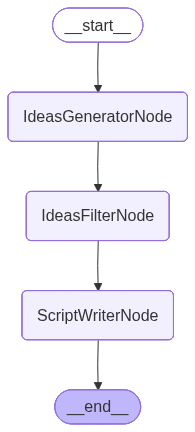

In [14]:
from IPython.display import Image, display

png_data = graph.get_graph().draw_mermaid_png()
display(Image(data=png_data))

In [15]:
result = graph.invoke(
        {
           "user_request" : "Create YouTube video ideas about AI agents.",
        }
    )

response : video_ideas=['Exploring the Future: How AI Agents Will Transform Everyday Life', 'Building Your Own AI Agent: A Step-by-Step Tutorial for Beginners', 'AI Agent Showdown: Comparing the Top 5 AI Assistants in 2025', 'The Ethics of AI Agents: Can They Be Trusted?', 'Behind the Scenes: How AI Agents Learn from Human Interaction']
idea='Behind the Scenes: How AI Agents Learn from Human Interaction'
content='# 🎬 Behind the Scenes: How AI Agents Learn from Human Interaction\n\n> **Script for a YouTube video**  \n> **Length:** ~10‑12 minutes  \n> **Tone:** Conversational, friendly, slightly informal but still professional.  \n> **Format:** Markdown with headings, bullet points, and clear cues for visuals/audio.\n\n---\n\n## 📽️ Opening\n\n**[Visual]**: Fast‑cut montage of robots, chatbots, and people interacting with devices.  \n**[Audio]**: Upbeat electronic music fades into a warm, inviting voice.\n\n> **Host (on camera)**  \n> “Hey everyone! Welcome back to *TechTalks*—the channel

In [16]:
result

{'user_request': 'Create YouTube video ideas about AI agents.',
 'video_ideas': ['Exploring the Future: How AI Agents Will Transform Everyday Life',
  'Building Your Own AI Agent: A Step-by-Step Tutorial for Beginners',
  'AI Agent Showdown: Comparing the Top 5 AI Assistants in 2025',
  'The Ethics of AI Agents: Can They Be Trusted?',
  'Behind the Scenes: How AI Agents Learn from Human Interaction'],
 'filtered_idea': 'Behind the Scenes: How AI Agents Learn from Human Interaction',
 'final_video_script': '# 🎬 Behind the Scenes: How AI Agents Learn from Human Interaction\n\n> **Script for a YouTube video**  \n> **Length:** ~10‑12 minutes  \n> **Tone:** Conversational, friendly, slightly informal but still professional.  \n> **Format:** Markdown with headings, bullet points, and clear cues for visuals/audio.\n\n---\n\n## 📽️ Opening\n\n**[Visual]**: Fast‑cut montage of robots, chatbots, and people interacting with devices.  \n**[Audio]**: Upbeat electronic music fades into a warm, inviti

In [20]:
print( result['final_video_script'])

# 🎬 Behind the Scenes: How AI Agents Learn from Human Interaction

> **Script for a YouTube video**  
> **Length:** ~10‑12 minutes  
> **Tone:** Conversational, friendly, slightly informal but still professional.  
> **Format:** Markdown with headings, bullet points, and clear cues for visuals/audio.

---

## 📽️ Opening

**[Visual]**: Fast‑cut montage of robots, chatbots, and people interacting with devices.  
**[Audio]**: Upbeat electronic music fades into a warm, inviting voice.

> **Host (on camera)**  
> “Hey everyone! Welcome back to *TechTalks*—the channel where we break down the tech that’s shaping our world. Today, we’re going behind the scenes of something that’s literally learning from us: AI agents. Ever wondered how those smart assistants or game bots get better the more you talk to them? Stick around, because we’re pulling back the curtain on the science, the data, and the human touch that powers it all.”

---

## 🎯 Hook

**[On‑screen text]**: “What if your phone could lea